# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HoursWorked          300 non-null    float64
 1   FocusScore           300 non-null    float64
 2   ProductivityScore    300 non-null    float64
 3   Department           300 non-null    object 
 4   YearsAtCompany       300 non-null    int64  
 5   TeamMeetingsPerWeek  300 non-null    int64  
 6   DeskLocation         300 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 16.5+ KB


In [15]:
df.describe()

,HoursWorked,FocusScore,ProductivityScore,YearsAtCompany,TeamMeetingsPerWeek
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,40.225333,6.061000,3114.163733,9.533333,3.003333
std,4.885138,2.076862,1248.635506,5.961040,1.756971
min,22.200000,1.000000,0.000000,0.000000,0.000000
25%,37.275000,4.500000,2254.552500,5.000000,2.000000
50%,40.600000,6.150000,3080.155000,9.000000,3.000000
75%,43.500000,7.625000,3958.905000,15.000000,4.000000
max,53.800000,10.000000,6299.200000,20.000000,9.000000


In [16]:
def calculate_r2(x, y):
    correlation = x.corr(y)
    return correlation ** 2

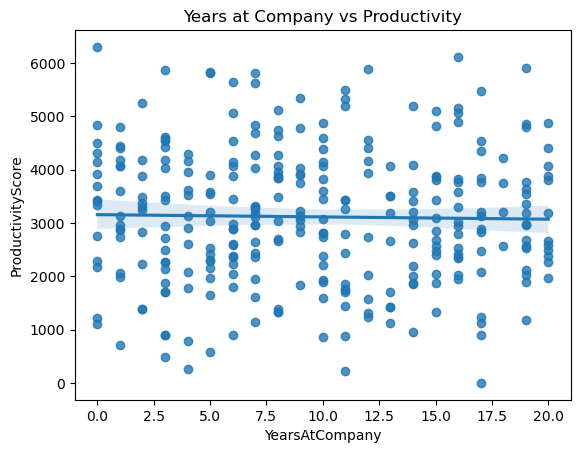

In [17]:
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Years at Company vs Productivity')
plt.show()

In [18]:
r2_years = calculate_r2(df['YearsAtCompany'], df['ProductivityScore'])
print("YearsAtCompany R²:", r2_years)

YearsAtCompany R²: 0.00041152919389670083


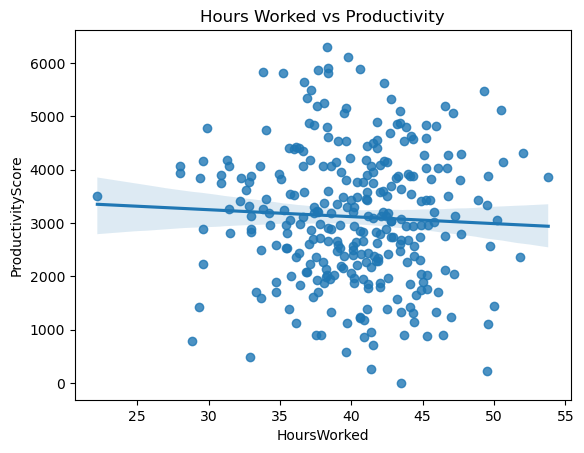

In [19]:
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df)
plt.title('Hours Worked vs Productivity')
plt.show()

In [20]:
r2_hours = calculate_r2(df['HoursWorked'], df['ProductivityScore'])
print("HoursWorked R²:", r2_hours)

HoursWorked R²: 0.002599935002265334


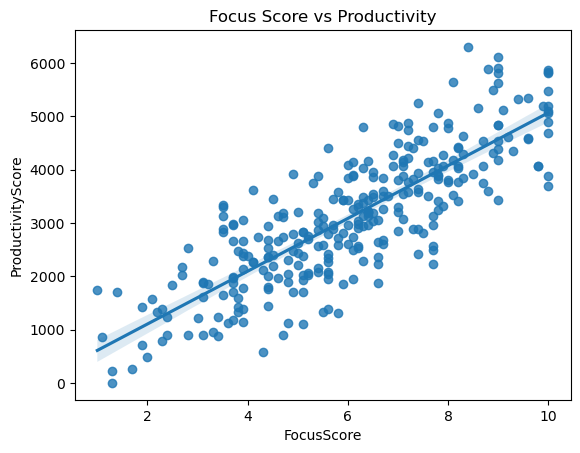

In [21]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Focus Score vs Productivity')
plt.show()

In [22]:
r2_focus = calculate_r2(df['FocusScore'], df['ProductivityScore'])
print("FocusScore R²:", r2_focus)

FocusScore R²: 0.6776960770307466


In [23]:
comparison = pd.DataFrame({
    'Feature': ['YearsAtCompany', 'HoursWorked', 'FocusScore'],
    'R_squared': [r2_years, r2_hours, r2_focus]
})

comparison.sort_values(by='R_squared', ascending=False)

,Feature,R_squared
2,FocusScore,0.677696
1,HoursWorked,0.002600
0,YearsAtCompany,0.000412


# Feature - Question 1

The feature with the strongest linear relationship with productivity is FocusScore, as it has the highest R-squared value. The regplot also shows a clearer linear trend compared to the other variables.

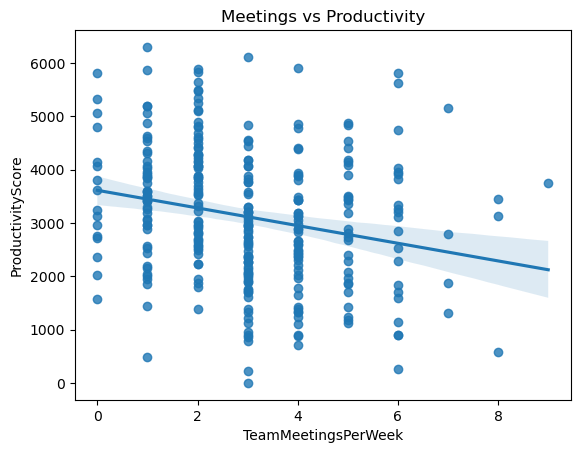

In [24]:
sns.regplot(x='TeamMeetingsPerWeek', y='ProductivityScore', data=df)
plt.title('Meetings vs Productivity')
plt.show()

In [25]:
r2_meetings = calculate_r2(df['TeamMeetingsPerWeek'], df['ProductivityScore'])
print("Meetings R²:", r2_meetings)

Meetings R²: 0.05424465123148916


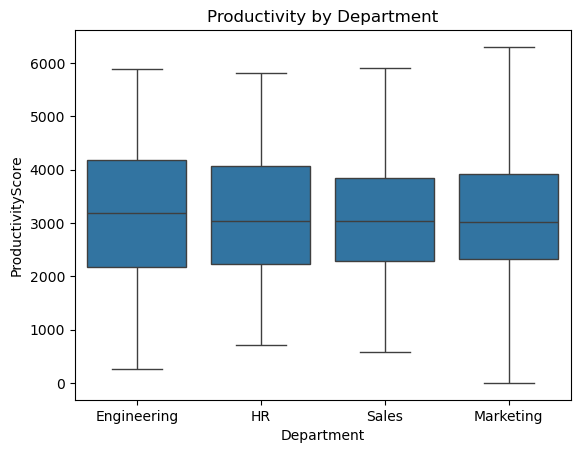

In [26]:
sns.boxplot(x='Department', y='ProductivityScore', data=df)
plt.title('Productivity by Department')
plt.show()

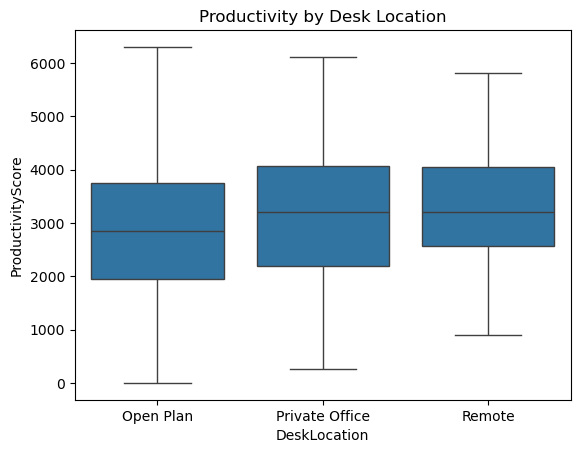

In [27]:
sns.boxplot(x='DeskLocation', y='ProductivityScore', data=df)
plt.title('Productivity by Desk Location')
plt.show()

# Regression Model

In [28]:
df.corr(numeric_only=True)

,HoursWorked,FocusScore,ProductivityScore,YearsAtCompany,TeamMeetingsPerWeek
HoursWorked,1.000000,-0.045176,-0.050990,0.090760,-0.019805
FocusScore,-0.045176,1.000000,0.823223,-0.039187,-0.313975
ProductivityScore,-0.050990,0.823223,1.000000,-0.020286,-0.232905
YearsAtCompany,0.090760,-0.039187,-0.020286,1.000000,0.014838
TeamMeetingsPerWeek,-0.019805,-0.313975,-0.232905,0.014838,1.000000


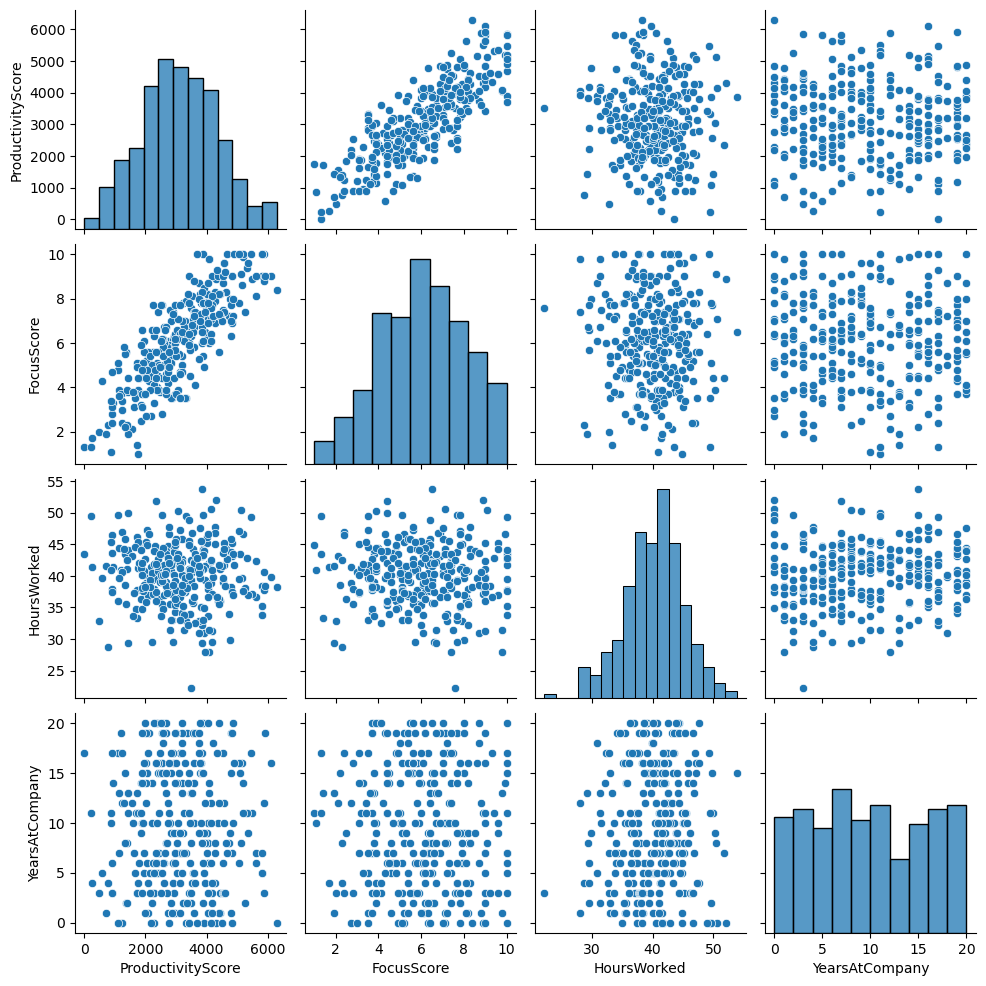

In [29]:
sns.pairplot(df[['ProductivityScore', 'FocusScore', 'HoursWorked', 'YearsAtCompany']])

# Summary
The analysis showed that FocusScore had the strongest linear relationship with productivity, based on the highest R-squared value. Hours worked also showed a moderate relationship, while years at the company had a weaker relationship. Additionally, meetings per week appeared to have a negative relationship with productivity, suggesting that more meetings may reduce employee output. Desk location also showed differences, with certain environments appearing more conducive to productivity.

# Recommendations
To improve productivity, the company should focus on increasing employee focus by reducing distractions, particularly in open plan environments. Reducing the number of meetings may also help employees dedicate more time to productive work. Additionally, providing quiet or private workspaces could improve concentration and output. Finally, reviewing administrative workload may help employees be productive during normal work hours without needing overtime.